# Análise de Redes Sociais: Rede de collabs do K-Pop
Neste notebook, vamos explorar uma rede de colaborações entre idols do K-pop. 
Nosso objetivo é construir o grafo da rede, analisar a formação de grupos e identificar os nós mais centrais e influentes usando métricas de centralidade.

## 1. Importação de Bibliotecas e Carregamento dos Dados
Primeiro, vamos importar os pacotes necessários que incluem `pandas` para manipulação de dados, `networkx` para criação e análise do grafo, e `matplotlib` para visualização.

In [15]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from networkx.algorithms import community as nx_community
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### 1.1 Carregamento e Criação do Grafo
Carregamos as arestas (conexões) a partir de um arquivo CSV, onde `source` e `target` representam os cantores colaborando entre si.

In [16]:
df = pd.read_csv("../Social Network Analysis/data/kpop_collab_network.csv",index_col=False)
df

,source,target
0,NCT U,NCT
1,SEULGI,Kassy
2,Whee In,GSoul
3,Eric Nam,Loco
4,CHEN,BAEKHYUN
...,...,...
402,SOYOU,KIHYUN
403,HEIZE,Crush
404,JOY,Paul Kim
405,Chantel 姚焯菲,Gigi炎明熹


In [17]:
# criando grafo
G = nx.from_pandas_edgelist(
    df,
    source="source",
    target="target"
)

### Resumo Estatístico da Rede

 **propriedades fundamentais** dessa rede são:

| Propriedade | Descrição |
|---|---|
| **Nós** |  artistas |
| **Arestas** |  colaborações |
| **Densidade** | Proporção de conexões existentes vs. possíveis |
| **Grau Médio** | Média de colaborações por artista |
| **Clustering Médio** | Tendência de vizinhos se conectarem entre si |
| **Componentes** | Partes desconexas da rede |

In [22]:
import networkx as nx
import numpy as np

# Métricas globais da rede
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
degrees = [d for _, d in G.degree()]
avg_degree = np.mean(degrees)
max_degree = max(degrees)
avg_clustering = nx.average_clustering(G)
num_components = nx.number_connected_components(G)
largest_cc = max(nx.connected_components(G), key=len)

print("=" * 40)
print("   RESUMO ESTATÍSTICO DA REDE K-POP")
print("=" * 40)
print(f"  Nós (artistas)              : {num_nodes}")
print(f"  Arestas (colaborações)      : {num_edges}")
print(f"  Densidade                   : {density:.4f}")
print(f"  Grau Médio                  : {avg_degree:.2f}")
print(f"  Grau Máximo                 : {max_degree}")
print(f"  Clustering Médio            : {avg_clustering:.4f}")
print(f"  Componentes Conectadas      : {num_components}")
print(f"  Maior Componentes Conectadas: {len(largest_cc)} nós")
print("=" * 40)


   RESUMO ESTATÍSTICO DA REDE K-POP
  Nós (artistas)              : 255
  Arestas (colaborações)      : 407
  Densidade                   : 0.0126
  Grau Médio                  : 3.19
  Grau Máximo                 : 20
  Clustering Médio            : 0.0996
  Componentes Conectadas      : 26
  Maior Componentes Conectadas: 186 nós


### 1.2 Visualização Inicial da Rede

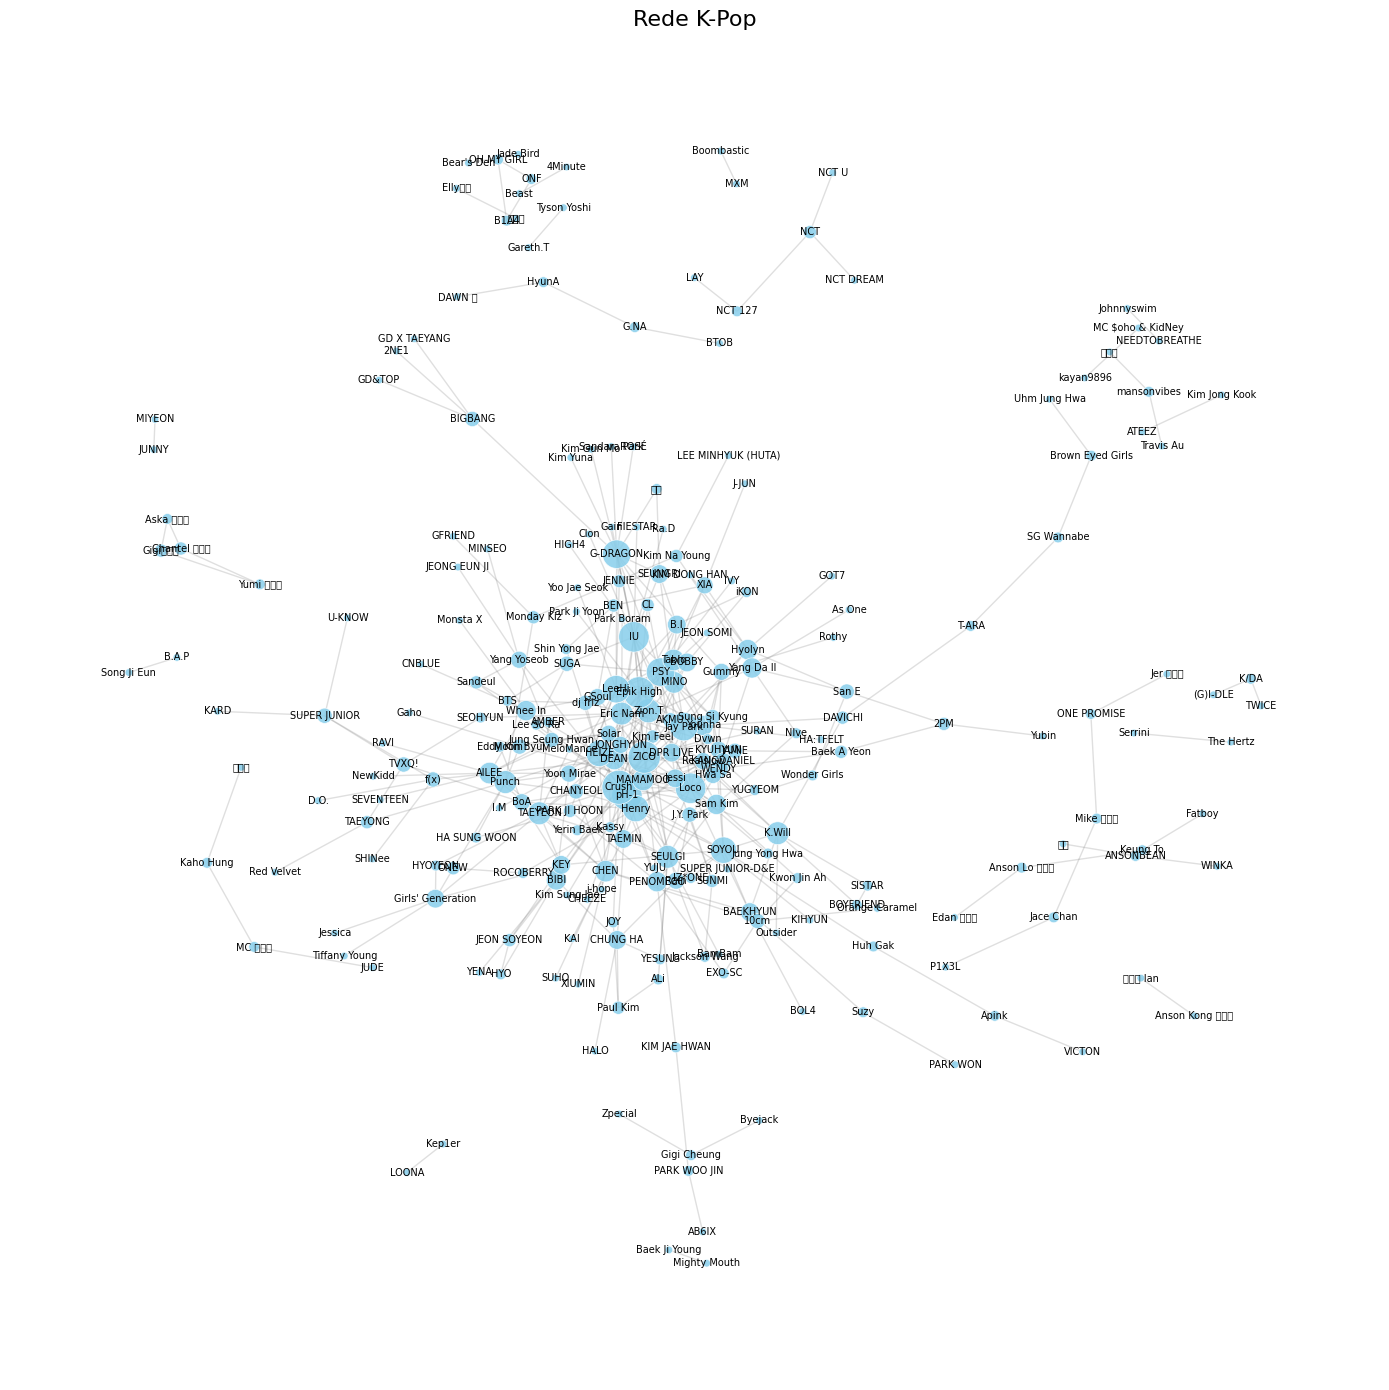

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

d = dict(G.degree())

plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.15, seed=42)

nx.draw_networkx_nodes(
    G, pos,
    node_size=[v * 30 for v in d.values()],
    node_color="skyblue",
    alpha=0.85,
    edgecolors='white',
    linewidths=0.5
)

nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=7)

plt.title("Rede K-Pop", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Centralidade de Grau e Ranking de Colaboração
A **Centralidade de Grau** (*Degree Centrality*) mede quantas conexões diretas cada nó possui na rede.
Aqui calculamos o grau absoluto de cada artista (número de colaborações diretas) e ordenamos os artistas em um ranking para identificar os mais colaborativos da rede.

In [25]:
degree = dict(G.degree())
ranking = sorted(degree.items(), key=lambda x: x[1], reverse=True)

In [24]:
for pos, (node, deg) in enumerate(ranking, start=1):
    print(f"{pos}º lugar: {node} → grau {deg}")

1º lugar: Crush → grau 20
2º lugar: ZICO → grau 18
3º lugar: Epik High → grau 17
4º lugar: Loco → grau 16
5º lugar: pH-1 → grau 16
6º lugar: IU → grau 16
7º lugar: G-DRAGON → grau 14
8º lugar: PSY → grau 14
9º lugar: Jay Park → grau 14
10º lugar: LeeHi → grau 13
11º lugar: Henry → grau 12
12º lugar: HEIZE → grau 12
13º lugar: SOYOU → grau 12
14º lugar: Zion.T → grau 10
15º lugar: SEULGI → grau 9
16º lugar: Eric Nam → grau 9
17º lugar: Punch → grau 9
18º lugar: K.Will → grau 9
19º lugar: TAEYEON → grau 9
20º lugar: CHEN → grau 8
21º lugar: MINO → grau 8
22º lugar: DEAN → grau 8
23º lugar: Tablo → grau 8
24º lugar: AILEE → grau 8
25º lugar: MAMAMOO → grau 8
26º lugar: Whee In → grau 7
27º lugar: Younha → grau 7
28º lugar: Hyolyn → grau 7
29º lugar: BIBI → grau 7
30º lugar: PENOMECO → grau 7
31º lugar: Yang Da Il → grau 7
32º lugar: Sam Kim → grau 7
33º lugar: BAEKHYUN → grau 6
34º lugar: BOBBY → grau 6
35º lugar: SEUNGRI → grau 6
36º lugar: DPR LIVE → grau 6
37º lugar: CHUNG HA → grau 6


#### 2.2 Degree Centrality Normalizada
Normalizamos a métrica de grau para obter uma medida de centralidade entre 0 e 1, facilitando a comparação entre diferentes grafos.

In [28]:
degree_centrality = nx.degree_centrality(G)
ranking = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)

for pos, (node, deg) in enumerate(ranking, start=1):
    print(f"{pos}º lugar: {node} → grau {deg}")

1º lugar: Crush → grau 0.07874015748031496
2º lugar: ZICO → grau 0.07086614173228346
3º lugar: Epik High → grau 0.06692913385826771
4º lugar: Loco → grau 0.06299212598425197
5º lugar: pH-1 → grau 0.06299212598425197
6º lugar: IU → grau 0.06299212598425197
7º lugar: G-DRAGON → grau 0.05511811023622047
8º lugar: PSY → grau 0.05511811023622047
9º lugar: Jay Park → grau 0.05511811023622047
10º lugar: LeeHi → grau 0.051181102362204724
11º lugar: Henry → grau 0.047244094488188976
12º lugar: HEIZE → grau 0.047244094488188976
13º lugar: SOYOU → grau 0.047244094488188976
14º lugar: Zion.T → grau 0.03937007874015748
15º lugar: SEULGI → grau 0.03543307086614173
16º lugar: Eric Nam → grau 0.03543307086614173
17º lugar: Punch → grau 0.03543307086614173
18º lugar: K.Will → grau 0.03543307086614173
19º lugar: TAEYEON → grau 0.03543307086614173
20º lugar: CHEN → grau 0.031496062992125984
21º lugar: MINO → grau 0.031496062992125984
22º lugar: DEAN → grau 0.031496062992125984
23º lugar: Tablo → grau 0.0

## 3. Propriedades Globais da Rede
Por fim, extraímos e visualizamos algumas métricas sobre a forma do grafo. Elas revelam a conectividade, distância média dos caminhos, e estrutura macro da comunidade observada.

#### 3.1 Centralidade de Intermediação (Betweenness Centrality)
A centralidade de intermediação mede a frequência com que um nó atua como uma 'ponte' no caminho mais curto entre outros dois nós. Nós com alta intermediação são fundamentais para o fluxo de informações na rede.

In [29]:
betweenness = nx.betweenness_centrality(G)
ranking = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)

for pos, (node, deg) in enumerate(ranking, start=1):
    print(f"{pos}º lugar: {node} → grau {deg}")

1º lugar: ZICO → grau 0.07835356967812493
2º lugar: pH-1 → grau 0.0688922464441172
3º lugar: Crush → grau 0.06587142924852141
4º lugar: G-DRAGON → grau 0.053399481938486364
5º lugar: Jay Park → grau 0.05235145182050311
6º lugar: Loco → grau 0.048592495090254643
7º lugar: IU → grau 0.048482543201476797
8º lugar: SOYOU → grau 0.04673550280301135
9º lugar: HEIZE → grau 0.036986658606209824
10º lugar: Punch → grau 0.03611431956628824
11º lugar: Henry → grau 0.03538949112762613
12º lugar: Epik High → grau 0.03520893686484684
13º lugar: PSY → grau 0.032465756701020164
14º lugar: LeeHi → grau 0.03212226178492736
15º lugar: Hyolyn → grau 0.031166919268304474
16º lugar: Eric Nam → grau 0.029323282315633938
17º lugar: CHEN → grau 0.029034197585180638
18º lugar: PENOMECO → grau 0.028377061176687424
19º lugar: AILEE → grau 0.027207745564445263
20º lugar: K.Will → grau 0.02560052279515545
21º lugar: DAVICHI → grau 0.024074084840945507
22º lugar: SEULGI → grau 0.024033279287577404
23º lugar: BAEKHYU

## 4. Detecção de Comunidades
A detecção de comunidades busca encontrar grupos de nós que estão mais densamente conectados entre si do que com o resto da rede. Utilizamos o algoritmo *Greedy Modularity* para particionar os artistas em comunidades ('panelinhas').

In [30]:
communities = nx_community.greedy_modularity_communities(G)

for i, c in enumerate(communities):
    print(f"Comunidade {i+1}: {list(c)}")

Comunidade 1: ['Clon', 'I.M', 'iKON', 'Gain', 'Kim Yuna', 'Loco', 'Sam Kim', 'CL', 'KANGDANIEL', 'Tablo', 'B.I', 'Ra.D', 'MINO', 'SEUNGRI', 'Yoo Jae Seok', 'G-DRAGON', 'Sandara Park', 'Dvwn', 'YUJU', 'YUGYEOM', 'Epik High', 'Jay Park', 'ZICO', 'Crush', 'JENNIE', 'ROSÉ', 'Kim Feel', 'SUGA', 'FIESTAR', 'BTS', 'HIGH4', 'Hwa Sa', '태양', 'HEIZE', 'AKMU', 'j-hope', 'BOBBY', 'Lee So Ra', 'SURAN', 'Jessi', 'Zion.T', 'IU', 'LeeHi', 'IVY', 'PSY', 'dj friz', 'DPR LIVE', 'Kim Gun Mo', 'DEAN', 'Park Ji Yoon']
Comunidade 2: ['Punch', 'CHEN', 'NewKidd', '10cm', 'KIM JAE HWAN', 'XIUMIN', 'SUHO', 'ROCOBERRY', 'AILEE', 'HA SUNG WOON', 'PENOMECO', 'EXO-SC', 'Orange Caramel', 'PARK WOO JIN', 'AB6IX', 'RAVI', 'Yoon Mirae', 'PARK JI HOON', 'ONEW', 'SEVENTEEN', 'CHANYEOL', 'Kwon Jin Ah']
Comunidade 3: ['Apink', 'Realslow', 'HA:TFELT', 'KIHYUN', 'Kim Sung Jae', 'Rothy', 'Jung Yong Hwa', 'CHEEZE', 'Sung Si Kyung', 'pH-1', 'Yerin Baek', 'Huh Gak', 'SOYOU', 'KYUHYUN', 'Younha', 'IZ*ONE', 'Henry', 'VICTON', 'Gummy

/tmp/ipykernel_52165/4226537107.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(communities))


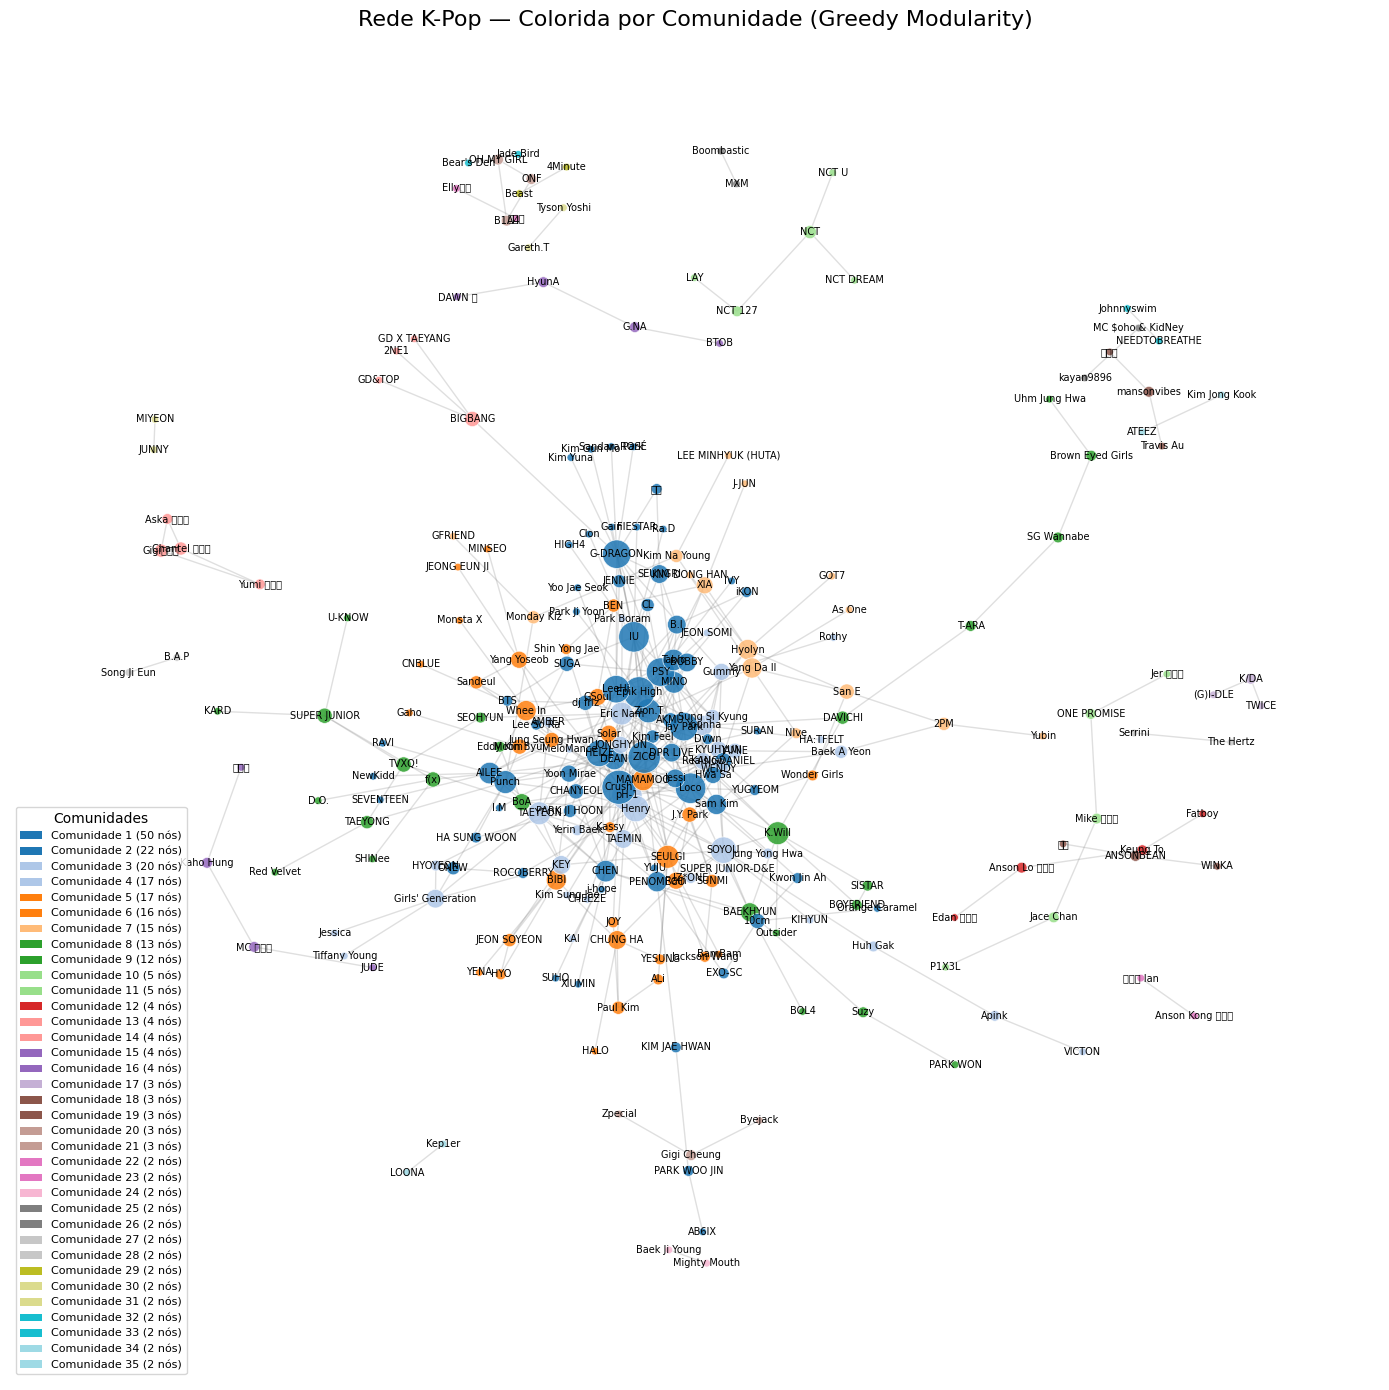

In [31]:
from networkx.algorithms import community as nx_community
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Detectar comunidades
communities = list(nx_community.greedy_modularity_communities(G))

# Criar mapa de cor: cada nó recebe o índice da sua comunidade
node_community = {}
for idx, comm in enumerate(communities):
    for node in comm:
        node_community[node] = idx

# Paleta de cores proporcional ao número de comunidades
cmap = cm.get_cmap("tab20", len(communities))
node_colors = [cmap(node_community[node]) for node in G.nodes()]

# Tamanho dos nós proporcional ao grau
d = dict(G.degree())

plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.15, seed=42)

nx.draw_networkx_nodes(
    G, pos,
    node_size=[v * 30 for v in d.values()],
    node_color=node_colors,
    alpha=0.85,
    edgecolors='white',
    linewidths=0.5
)
nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=7, font_color='black')

# Legenda das comunidades
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=cmap(i), label=f"Comunidade {i+1} ({len(communities[i])} nós)")
    for i in range(len(communities))
]
plt.legend(
    handles=legend_handles,
    loc='lower left',
    fontsize=8,
    title="Comunidades",
    framealpha=0.8
)

plt.title("Rede K-Pop — Colorida por Comunidade (Greedy Modularity)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


#### 4.1 Distribuição do Tamanho das Comunidades

In [32]:
for i, comm in enumerate(communities):
    print(f"Comunidade {i+1}: {len(comm)} nós")

Comunidade 1: 50 nós
Comunidade 2: 22 nós
Comunidade 3: 20 nós
Comunidade 4: 17 nós
Comunidade 5: 17 nós
Comunidade 6: 16 nós
Comunidade 7: 15 nós
Comunidade 8: 13 nós
Comunidade 9: 12 nós
Comunidade 10: 5 nós
Comunidade 11: 5 nós
Comunidade 12: 4 nós
Comunidade 13: 4 nós
Comunidade 14: 4 nós
Comunidade 15: 4 nós
Comunidade 16: 4 nós
Comunidade 17: 3 nós
Comunidade 18: 3 nós
Comunidade 19: 3 nós
Comunidade 20: 3 nós
Comunidade 21: 3 nós
Comunidade 22: 2 nós
Comunidade 23: 2 nós
Comunidade 24: 2 nós
Comunidade 25: 2 nós
Comunidade 26: 2 nós
Comunidade 27: 2 nós
Comunidade 28: 2 nós
Comunidade 29: 2 nós
Comunidade 30: 2 nós
Comunidade 31: 2 nós
Comunidade 32: 2 nós
Comunidade 33: 2 nós
Comunidade 34: 2 nós
Comunidade 35: 2 nós


#### 4.2 Explorando uma Comunidade Específica
Podemos isolar e analisar especificamente uma das comunidades geradas para entender sua composição individual.

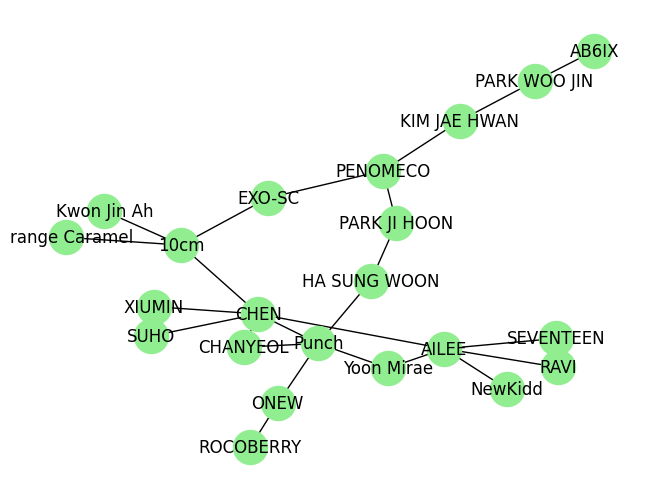

In [34]:
comm0 = list(communities[1]) # troca o numero do index do array pra ver outras comunidades
sub = G.subgraph(comm0)

nx.draw(sub, with_labels=True, node_color='lightgreen', node_size=600)
plt.show()

## 5. Hubs e Métricas Estruturais
A **Densidade** indica quão conectada a rede está em comparação com o máximo de conexões possíveis. Redes sociais reais geralmente são muito esparsas (baixa densidade).

In [35]:
nx.density(G)

0.012567546703720858

## 6.Tabela Comparativa: Top 10 Artistas por Centralidade

Cada métrica de centralidade revela um papel diferente na rede:

| Métrica | O que mede | Significa... |
|---|---|---|
| **Degree** | Conexões diretas | Artista mais colaborativo |
| **Betweenness** | Passagem em caminhos mais curtos | Artista-ponte entre grupos |
| **Eigenvector** | Conexão com nós importantes | Artista conectado aos mais influentes |
| **PageRank** | Influência propagada pela rede | Influência global |
| **Clustering** | Coesão dos vizinhos | Pertence a um grupo fechado? |

In [37]:
import pandas as pd

degree_c   = nx.degree_centrality(G)
between_c  = nx.betweenness_centrality(G)
eigen_c    = nx.eigenvector_centrality(G, max_iter=1000)
pagerank_c = nx.pagerank(G)
clust_c    = nx.clustering(G)
degree_abs = dict(G.degree())

df_metrics = pd.DataFrame({
    'Artista'     : list(G.nodes()),
    'Grau'        : [degree_abs[n] for n in G.nodes()],
    'Degree C.'   : [round(degree_c[n], 4) for n in G.nodes()],
    'Betweenness' : [round(between_c[n], 4) for n in G.nodes()],
    'Eigenvector' : [round(eigen_c[n], 4) for n in G.nodes()],
    'PageRank'    : [round(pagerank_c[n], 4) for n in G.nodes()],
    'Clustering'  : [round(clust_c[n], 4) for n in G.nodes()],
})

# Top 10 por betweenness (artistas-ponte mais relevantes)
top10 = df_metrics.sort_values('Betweenness', ascending=False).head(10).reset_index(drop=True)
top10.index = top10.index + 1
top10


,Artista,Grau,Degree C.,Betweenness,Eigenvector,PageRank,Clustering
1,ZICO,18,0.0709,0.0784,0.2671,0.0148,0.1046
2,pH-1,16,0.0630,0.0689,0.1784,0.0139,0.0667
3,Crush,20,0.0787,0.0659,0.3344,0.0157,0.1316
4,G-DRAGON,14,0.0551,0.0534,0.1358,0.0136,0.0769
5,Jay Park,14,0.0551,0.0524,0.2397,0.0110,0.1429
6,Loco,16,0.0630,0.0486,0.2192,0.0129,0.0917
7,IU,16,0.0630,0.0485,0.2127,0.0142,0.0667
8,SOYOU,12,0.0472,0.0467,0.0803,0.0110,0.0758
9,HEIZE,12,0.0472,0.0370,0.1657,0.0099,0.1061
10,Punch,9,0.0354,0.0361,0.0421,0.0088,0.0556


### Bonus visualização da maior comunidade:
Isolamos a maior comunidade detectada pelo algoritmo *Greedy Modularity*  
para uma análise mais detalhada. Nessa visualização:

- O **tamanho** dos nós representa o grau (número de colaborações)
- A **intensidade da cor** representa o *betweenness* (importância como ponte)
- As **arestas cinzas** ligam artistas que colaboraram juntos

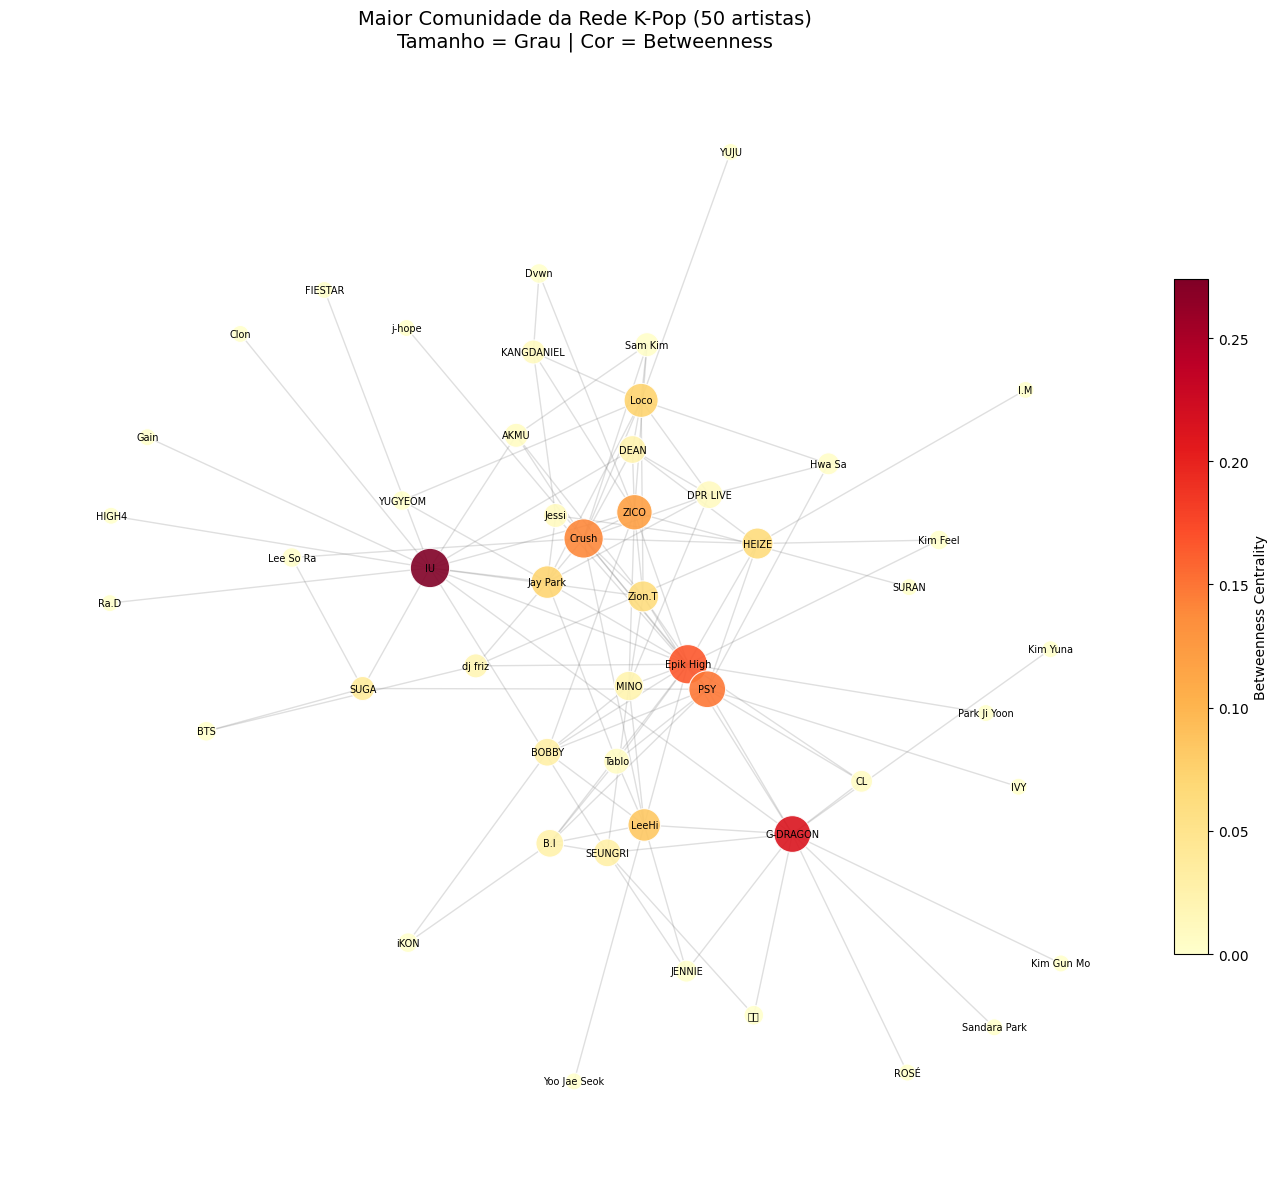

In [39]:
from networkx.algorithms import community as nx_community

# Detectar comunidades e obter a maior
comms = list(nx_community.greedy_modularity_communities(G))
maior_comm = max(comms, key=len)
subG = G.subgraph(maior_comm)

# Métricas no subgrafo
sub_degree  = dict(subG.degree())
sub_between = nx.betweenness_centrality(subG)

node_sizes  = [sub_degree[n] * 50 + 100 for n in subG.nodes()]
node_colors = [sub_between[n] for n in subG.nodes()]

pos_sub = nx.spring_layout(subG, k=0.4, seed=42)

fig, ax = plt.subplots(figsize=(14, 12))

nodes = nx.draw_networkx_nodes(
    subG, pos_sub,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.YlOrRd,
    alpha=0.9,
    edgecolors='white',
    linewidths=0.8,
    ax=ax
)
nx.draw_networkx_edges(subG, pos_sub, alpha=0.25, edge_color='gray', ax=ax)
nx.draw_networkx_labels(subG, pos_sub, font_size=7, ax=ax)

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
     norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label('Betweenness Centrality', fontsize=10)

ax.set_title(
    f'Maior Comunidade da Rede K-Pop ({len(maior_comm)} artistas)\n'
    'Tamanho = Grau | Cor = Betweenness',
    fontsize=14
)
ax.axis('off')
plt.tight_layout()
plt.show()
